# 1-Hour PyTorch Lab: Activation Functions and the Update Rule

**Format:** Google Colab | **Level:** introductory deep learning | **Runtime:** CPU

> **Big question:** How does the activation function decide whether a one-neuron model can learn, and how fast it learns?

## Learning outcomes
By the end of the lab, students will be able to:

1. compute a perceptron's weighted sum, activation, loss, and weight update;
2. use PyTorch autograd to inspect activation-function gradients;
3. explain why the threshold/step function cannot be trained by ordinary gradient descent; and
4. compare sigmoid and tanh at the center and in saturated regions.

## 60-minute run of show

| Time | Mode | Task |
|---:|---|---|
| 0-5 min | Launch | Predict which activation learns fastest |
| 5-15 min | Teacher demo 1 | Plot step, sigmoid, tanh and their gradients |
| 15-25 min | Student activity 1 | Build an activation-gradient probe |
| 25-35 min | Teacher demo 2 | Trace one sigmoid update with autograd |
| 35-50 min | Student activity 2 | Implement and test one update |
| 50-57 min | Pair challenge | Investigate saturation and step size |
| 57-60 min | Exit ticket | Explain the result in words |

### Teacher preparation
Open in Colab and choose **Runtime > Run all** before class. No GPU is needed. Solution cells are at the end and collapsed by default. Ask students to work in pairs during the two activities.

## 0. Launch question (0-5 min)

A single neuron computes

$$z=wx+b, \qquad \hat y=f(z), \qquad L=\tfrac12(\hat y-y)^2.$$

Gradient descent updates the weight using

$$w_{new}=w_{old}-\alpha\frac{\partial L}{\partial w}, \qquad\frac{\partial L}{\partial w}=(\hat y-y)f'(z)x.$$

**Predict before running code:** Which activation will make the largest update near $z=0$: step, sigmoid, or tanh? Give one reason.

Your prediction: `____________________________________________________________`

In [1]:
import math
import torch
import matplotlib.pyplot as plt

torch.manual_seed(7)
torch.set_printoptions(precision=6, sci_mode=False)
print(f"PyTorch {torch.__version__} | device: CPU")

PyTorch 2.11.0+cpu | device: CPU


## 1. Teacher demo: outputs and gradients (5-15 min)

Run the next cell and read each row vertically: the top plot is $f(z)$ and the bottom plot is $f'(z)$.

**Teacher talk track**

- The step function returns a decision, but its slope is zero almost everywhere and undefined at $z=0$. A PyTorch comparison such as `z >= 0` is disconnected from autograd.
- Sigmoid is smooth and has derivative $\sigma(z)(1-\sigma(z))$, with maximum $0.25$.
- Tanh is smooth and has derivative $1-\tanh^2(z)$, with maximum $1$.
- Both smooth functions saturate: far from zero, their gradients become small.

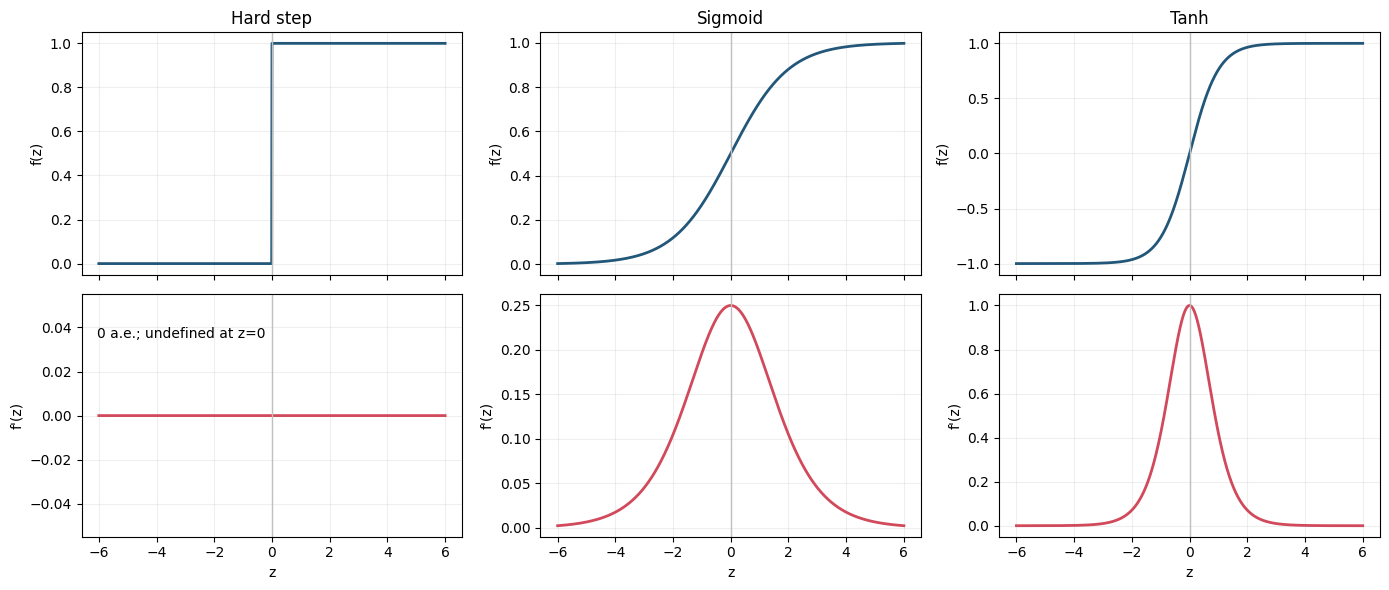

At z=0: sigmoid'=0.25, tanh'=1.00
Hard-step output requires grad? False


In [2]:
z = torch.linspace(-6, 6, 1201, requires_grad=True)

step_y = (z >= 0).float()
sigmoid_y = torch.sigmoid(z)
tanh_y = torch.tanh(z)

# A hard comparison has no grad_fn. Its mathematical derivative is 0
# almost everywhere and undefined at 0, so we display 0 away from the jump.
step_grad = torch.zeros_like(z)
sigmoid_grad = torch.autograd.grad(sigmoid_y.sum(), z, retain_graph=True)[0]
tanh_grad = torch.autograd.grad(tanh_y.sum(), z)[0]

names = ["Hard step", "Sigmoid", "Tanh"]
outputs = [step_y.detach(), sigmoid_y.detach(), tanh_y.detach()]
grads = [step_grad.detach(), sigmoid_grad.detach(), tanh_grad.detach()]

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
for col, (name, out, grad) in enumerate(zip(names, outputs, grads)):
    axes[0, col].plot(z.detach(), out, color="#22577A", linewidth=2)
    axes[0, col].set_title(name)
    axes[0, col].set_ylabel("f(z)")
    axes[1, col].plot(z.detach(), grad, color="#D1495B", linewidth=2)
    axes[1, col].set_ylabel("f'(z)")
    axes[1, col].set_xlabel("z")
    for ax in axes[:, col]:
        ax.axvline(0, color="0.75", linewidth=1)
        ax.grid(alpha=0.2)
axes[1, 0].text(0.04, 0.82, "0 a.e.; undefined at z=0", transform=axes[1, 0].transAxes)
plt.tight_layout()
plt.show()

center = len(z) // 2
print(f"At z=0: sigmoid'={sigmoid_grad[center].item():.2f}, tanh'={tanh_grad[center].item():.2f}")
print("Hard-step output requires grad?", step_y.requires_grad)

### Check for understanding

Ask students to answer aloud:

1. Why can the step function make a decision but not learn through ordinary backpropagation?
2. Where are sigmoid and tanh most sensitive to a change in $z$?
3. What happens to the gradient when $|z|$ becomes large?

## 2. Student activity 1: activation-gradient probe (15-25 min)

Complete `student_probe` so that it returns `(activation, gradient)` for one scalar input.

Requirements:

- support `name == "sigmoid"` and `name == "tanh"`;
- create `z` with `requires_grad=True`;
- use `torch.autograd.grad`;
- return ordinary Python numbers using `.item()`.

Then set `A1_READY = True` and run the tests. **Do not use the derivative formulas directly.**

In [4]:
A1_READY = False  # Change to True after completing the TODOs.

def student_probe(name, value):
    # TODO 1: create a scalar float tensor z that tracks gradients
    # z = ...

    # TODO 2: apply the requested activation
    # if name == "sigmoid":
    #     activation = ...
    # elif name == "tanh":
    #     activation = ...
    # else:
    #     raise ValueError("name must be 'sigmoid' or 'tanh'")

    # TODO 3: ask autograd for d(activation)/dz
    # gradient = ...

    # TODO 4: return two Python numbers
    return None, None

if not A1_READY:
    print("Complete student_probe, change A1_READY to True, and run again.")
else:
    s0 = student_probe("sigmoid", 0.0)
    t0 = student_probe("tanh", 0.0)
    assert math.isclose(s0[0], 0.5, abs_tol=1e-6)
    assert math.isclose(s0[1], 0.25, abs_tol=1e-6)
    assert math.isclose(t0[0], 0.0, abs_tol=1e-6)
    assert math.isclose(t0[1], 1.0, abs_tol=1e-6)
    print("Tests passed!")
    for value in [-4.0, 0.0, 4.0]:
        print(value, student_probe("sigmoid", value), student_probe("tanh", value))

Complete student_probe, change A1_READY to True, and run again.


### Activity 1 evidence table

Use your function at $z=-4,0,4$ and record the gradients to three decimals.

| $z$ | sigmoid gradient | tanh gradient | Which is larger? |
|---:|---:|---:|---|
| -4 |  |  |  |
| 0 |  |  |  |
| 4 |  |  |  |

**One-sentence conclusion:** `________________________________________________________`

## 3. Teacher demo: trace one sigmoid update (25-35 min)

We reproduce the lecture case $x=2$, $w=1$, $b=0$, $y=0$, and $\alpha=0.5$. Pause after each printed line and connect it to the chain rule.

Expected path:

$$x \rightarrow z \rightarrow \hat y \rightarrow L \rightarrow \frac{\partial L}{\partial w} \rightarrow w_{new}.$$

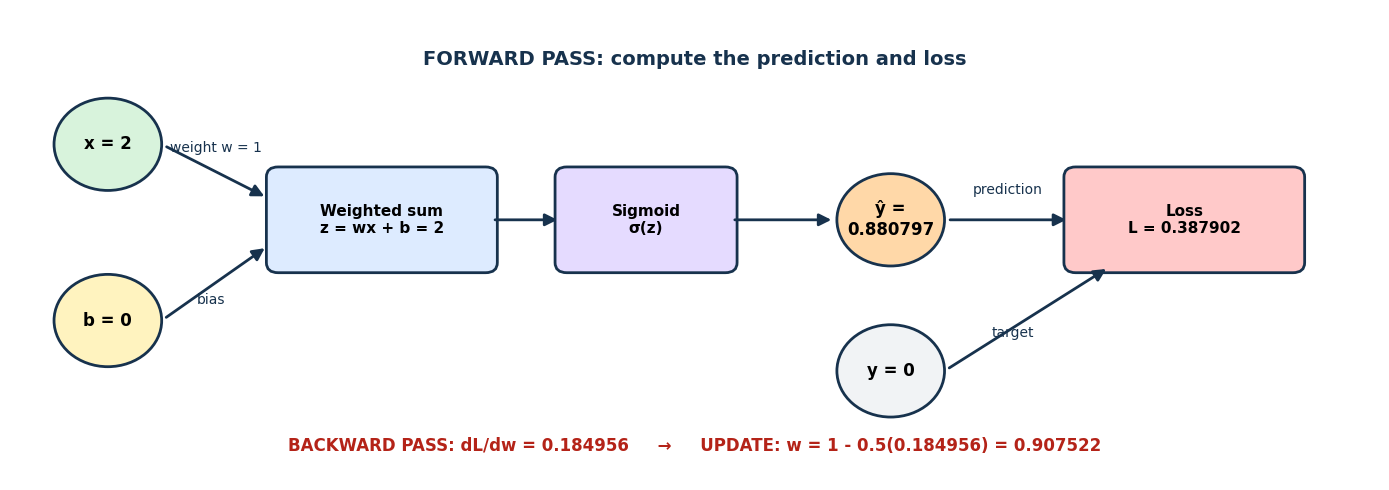

In [6]:
from matplotlib.patches import Circle, FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(-0.6, 5)
ax.axis("off")

def circle_node(xy, text, color):
    node = Circle(xy, 0.55, facecolor=color, edgecolor="#17324D", linewidth=2)
    ax.add_patch(node)
    ax.text(*xy, text, ha="center", va="center", fontsize=12, fontweight="bold")

def box_node(xy, width, text, color):
    x0, y0 = xy[0] - width / 2, xy[1] - 0.55
    node = FancyBboxPatch(
        (x0, y0), width, 1.1,
        boxstyle="round,pad=0.08,rounding_size=0.12",
        facecolor=color, edgecolor="#17324D", linewidth=2,
    )
    ax.add_patch(node)
    ax.text(*xy, text, ha="center", va="center", fontsize=11, fontweight="bold")

def arrow(start, end, label=None, label_xy=None, color="#17324D"):
    ax.add_patch(FancyArrowPatch(
        start, end, arrowstyle="-|>", mutation_scale=18,
        linewidth=2, color=color, shrinkA=4, shrinkB=4,
    ))
    if label:
        lx, ly = label_xy or ((start[0] + end[0]) / 2, (start[1] + end[1]) / 2 + 0.25)
        ax.text(lx, ly, label, ha="center", va="center", fontsize=10, color=color)

# Forward-pass nodes with the lecture values.
circle_node((1.0, 3.4), "x = 2", "#D8F3DC")
circle_node((1.0, 1.3), "b = 0", "#FFF3BF")
box_node((3.8, 2.5), 2.2, "Weighted sum\nz = wx + b = 2", "#DDEBFF")
box_node((6.5, 2.5), 1.7, "Sigmoid\nσ(z)", "#E5DBFF")
circle_node((9.0, 2.5), "ŷ =\n0.880797", "#FFD8A8")
circle_node((9.0, 0.7), "y = 0", "#F1F3F5")
box_node((12.0, 2.5), 2.3, "Loss\nL = 0.387902", "#FFC9C9")

arrow((1.55, 3.4), (2.65, 2.75), "weight w = 1", (2.1, 3.35))
arrow((1.55, 1.3), (2.65, 2.2), "bias", (2.05, 1.55))
arrow((4.9, 2.5), (5.65, 2.5))
arrow((7.35, 2.5), (8.45, 2.5))
arrow((9.55, 2.5), (10.85, 2.5), "prediction", (10.2, 2.85))
arrow((9.55, 0.7), (11.25, 1.95), "target", (10.25, 1.15))

ax.text(
    7.0, 4.35,
    "FORWARD PASS: compute the prediction and loss",
    ha="center", fontsize=14, fontweight="bold", color="#17324D",
)
ax.text(
    7.0, -0.25,
    "BACKWARD PASS: dL/dw = 0.184956     →     UPDATE: w = 1 - 0.5(0.184956) = 0.907522",
    ha="center", fontsize=12, fontweight="bold", color="#B42318",
)
plt.tight_layout()
plt.show()

In [7]:
x = torch.tensor(2.0)
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
target = torch.tensor(0.0)
alpha = 0.5

z = w * x + b
prediction = torch.sigmoid(z)
loss = 0.5 * (prediction - target) ** 2
loss.backward()

sigmoid_slope = prediction.detach() * (1 - prediction.detach())
manual_grad = (prediction.detach() - target) * sigmoid_slope * x
with torch.no_grad():
    new_w = w - alpha * w.grad

print(f"1. weighted sum z              = {z.item():.6f}")
print(f"2. prediction sigmoid(z)      = {prediction.item():.6f}")
print(f"3. error (prediction-target) = {(prediction-target).item():.6f}")
print(f"4. sigmoid slope f'(z)        = {sigmoid_slope.item():.6f}")
print(f"5. manual dL/dw               = {manual_grad.item():.6f}")
print(f"6. autograd dL/dw             = {w.grad.item():.6f}")
print(f"7. updated weight             = {new_w.item():.6f}")

assert torch.allclose(manual_grad, w.grad, atol=1e-6)
assert math.isclose(new_w.item(), 0.907522, abs_tol=1e-6)
print("Manual chain rule and PyTorch autograd agree.")

1. weighted sum z              = 2.000000
2. prediction sigmoid(z)      = 0.880797
3. error (prediction-target) = 0.880797
4. sigmoid slope f'(z)        = 0.104994
5. manual dL/dw               = 0.184956
6. autograd dL/dw             = 0.184956
7. updated weight             = 0.907522
Manual chain rule and PyTorch autograd agree.


### Direction check

The target is $0$ but the prediction is positive, so the prediction must decrease. Sigmoid increases with $z$, $z=wx+b$, and $x>0$; therefore $w$ must **decrease**. The update $1.000000 \rightarrow 0.907522$ passes this check.

Ask: *What would happen to the size of the step if we doubled the learning rate $\alpha$?*

## 4. Student activity 2: implement one update (35-50 min)

Complete a reusable function for a one-neuron update. Use PyTorch autograd - do not type a derivative formula.

Your function must:

1. create trainable scalar tensors for `w` and `b`;
2. calculate $z=wx+b$;
3. apply sigmoid or tanh;
4. calculate $L=\tfrac12(\hat y-y)^2$ and call `.backward()`;
5. calculate the new weight inside `torch.no_grad()`; and
6. return a dictionary with the requested values.

In [8]:
A2_READY = False  # Change to True after completing the TODOs.

def student_one_update(x_value, w_value, b_value, y_value, alpha, activation_name):
    # TODO 1: create x, w, b, and target tensors. Only w and b need gradients.
    # x = ...
    # w = ...
    # b = ...
    # target = ...

    # TODO 2: weighted sum and activation
    # z = ...
    # if activation_name == "sigmoid": ...
    # elif activation_name == "tanh": ...
    # else: raise ValueError(...)

    # TODO 3: squared-error loss and backward pass
    # loss = ...
    # loss.backward()

    # TODO 4: update w without tracking a new graph
    # with torch.no_grad():
    #     new_w = ...

    # TODO 5: return Python numbers
    # return {"z": ..., "prediction": ..., "loss": ...,
    #         "gradient": ..., "new_w": ...}
    return None

if not A2_READY:
    print("Complete student_one_update, change A2_READY to True, and run again.")
else:
    result = student_one_update(2, 1, 0, 0, 0.5, "sigmoid")
    assert math.isclose(result["z"], 2.0, abs_tol=1e-6)
    assert math.isclose(result["gradient"], 0.184956, abs_tol=1e-6)
    assert math.isclose(result["new_w"], 0.907522, abs_tol=1e-6)
    print("Tests passed!", result)

Tests passed!
{'z': 2.0, 'prediction': 0.8807970285415649, 'loss': 0.3879016935825348, 'gradient': 0.1849561482667923, 'new_w': 0.9075219035148621}


### Activity 2 experiments

After your tests pass, run these cases and record what changes.

1. Change $\alpha$ from `0.5` to `1.0`. Does the gradient change? Does the update size change?
2. Change the target from `0` to `1`. Does the weight move up or down? Why?
3. Use `activation_name="tanh"` with `x=1, w=0, b=0, y=1, alpha=1`. What is the new weight?

```python
# Suggested calls after A2_READY is True:
student_one_update(2, 1, 0, 0, 1.0, "sigmoid")
student_one_update(2, 1, 0, 1, 0.5, "sigmoid")
student_one_update(1, 0, 0, 1, 1.0, "tanh")
```

**Direction explanation:** `_________________________________________________________`

## 5. Pair challenge: center versus saturation (50-57 min)

The next cell is teacher-provided experiment code. Before running it, predict:

- At $z=0$, why should tanh move farther than sigmoid?
- At $z=4$, will both activations still make useful updates?

The experiment keeps $x=1$, $y=1$, and $\alpha=1$. It sets $b=z$ and starts $w=0$, so the initial weighted sum is exactly the requested value.

In [ ]:
def teacher_reference_update(z_value, activation_name):
    x = torch.tensor(1.0)
    w = torch.tensor(0.0, requires_grad=True)
    b = torch.tensor(float(z_value), requires_grad=True)
    target = torch.tensor(1.0)
    z = w * x + b
    prediction = torch.sigmoid(z) if activation_name == "sigmoid" else torch.tanh(z)
    loss = 0.5 * (prediction - target) ** 2
    loss.backward()
    return prediction.item(), w.grad.item(), (w - w.grad).item()

print(f"{'z':>4} {'activation':>10} {'prediction':>12} {'dL/dw':>12} {'new w':>12}")
print("-" * 56)
for z_value in [0.0, 2.0, 4.0]:
    for activation_name in ["sigmoid", "tanh"]:
        pred, grad, new_w = teacher_reference_update(z_value, activation_name)
        print(f"{z_value:4.1f} {activation_name:>10} {pred:12.6f} {grad:12.6f} {new_w:12.6f}")

sigmoid_center = teacher_reference_update(0, "sigmoid")[2]
tanh_center = teacher_reference_update(0, "tanh")[2]
print(f"\nAt z=0, tanh step / sigmoid step = {tanh_center / sigmoid_center:.1f}x")

### Challenge discussion

1. At $z=0$, sigmoid predicts $0.5$ and has slope $0.25$; tanh predicts $0$ and has slope $1$. Both the **error term** and **derivative term** differ, so the tanh step is $2\times4=8$ times larger.
2. A small update is not automatically bad - near the correct target, it can mean the model is nearly done. Saturation is a problem when the prediction is still wrong but the derivative is tiny.
3. Tanh is not always superior. Activation choice depends on the task, target encoding, architecture, and loss.

## 6. Exit ticket (57-60 min)

Answer each in one sentence.

1. Why does a hard step fail under ordinary gradient descent?
2. What two factors made the tanh update at $z=0$ eight times the sigmoid update?
3. If a model is confidently wrong in a saturated region, what happens to learning?

**My answers**

1. `________________________________________________________________________`
2. `________________________________________________________________________`
3. `________________________________________________________________________`

# Instructor solutions

These cells are collapsed by default. Reveal them during the debrief or share after submission.

In [ ]:
def solution_probe(name, value):
    z = torch.tensor(float(value), requires_grad=True)
    if name == "sigmoid":
        activation = torch.sigmoid(z)
    elif name == "tanh":
        activation = torch.tanh(z)
    else:
        raise ValueError("name must be 'sigmoid' or 'tanh'")
    gradient = torch.autograd.grad(activation, z)[0]
    return activation.item(), gradient.item()

for value in [-4.0, 0.0, 4.0]:
    print(value, solution_probe("sigmoid", value), solution_probe("tanh", value))

# Rounded gradient table:
# z=-4: sigmoid 0.018, tanh 0.001 -> sigmoid larger
# z= 0: sigmoid 0.250, tanh 1.000 -> tanh larger
# z= 4: sigmoid 0.018, tanh 0.001 -> sigmoid larger

In [ ]:
def solution_one_update(x_value, w_value, b_value, y_value, alpha, activation_name):
    x = torch.tensor(float(x_value))
    w = torch.tensor(float(w_value), requires_grad=True)
    b = torch.tensor(float(b_value), requires_grad=True)
    target = torch.tensor(float(y_value))
    z = w * x + b
    if activation_name == "sigmoid":
        prediction = torch.sigmoid(z)
    elif activation_name == "tanh":
        prediction = torch.tanh(z)
    else:
        raise ValueError("activation_name must be 'sigmoid' or 'tanh'")
    loss = 0.5 * (prediction - target) ** 2
    loss.backward()
    with torch.no_grad():
        new_w = w - alpha * w.grad
    return {
        "z": z.item(), "prediction": prediction.item(),
        "loss": loss.item(), "gradient": w.grad.item(),
        "new_w": new_w.item(),
    }

print(solution_one_update(2, 1, 0, 0, 0.5, "sigmoid"))
print(solution_one_update(1, 0, 0, 1, 1.0, "tanh"))

## Exit-ticket key

1. The hard step has zero derivative almost everywhere (and is undefined at the jump), so it supplies no useful gradient for the update.
2. At $z=0$, tanh has twice the error magnitude and four times the derivative, giving an update $2\times4=8$ times larger.
3. If the prediction is wrong but the activation derivative is tiny, the gradient and weight update become tiny, so learning slows or stalls.